# Exploratory Data Analysis (EDA)

This notebook explores the relationship between menstrual cycle phases and symptoms such as mood, cramps, and energy.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("clue_daily_data.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

Saving clue_daily_data.csv to clue_daily_data.csv


## Phase Creation

We categorize each day into menstrual, premenstrual, or other phases.

In [3]:
def assign_phase(row):
    if row["bleeding"] == 1:
        return "menstrual"
    elif row["cycle_day"] >= 28:
        return "premenstrual"
    else:
        return "other"

df["phase"] = df.apply(assign_phase, axis=1)

## Mood Analysis

We examine how mood changes across cycle phases.

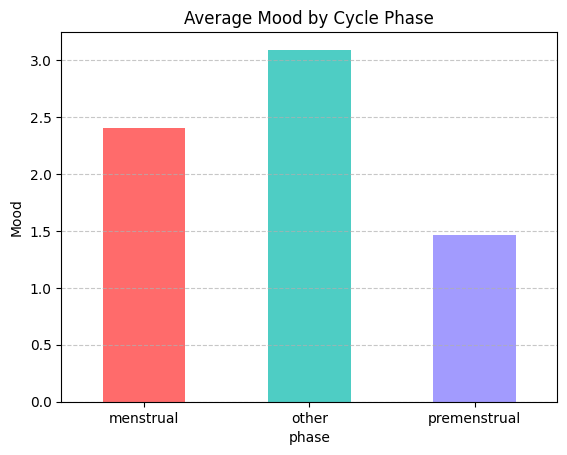

In [4]:
df.groupby("phase")["mood"].mean().plot(
    kind="bar",
    color=["#ff6b6b", "#4ecdc4", "#a29bfe"]
)

plt.title("Average Mood by Cycle Phase")
plt.ylabel("Mood")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Mood is highest during the non-menstrual phase and lowest during the premenstrual phase.

## Cramps Analysis

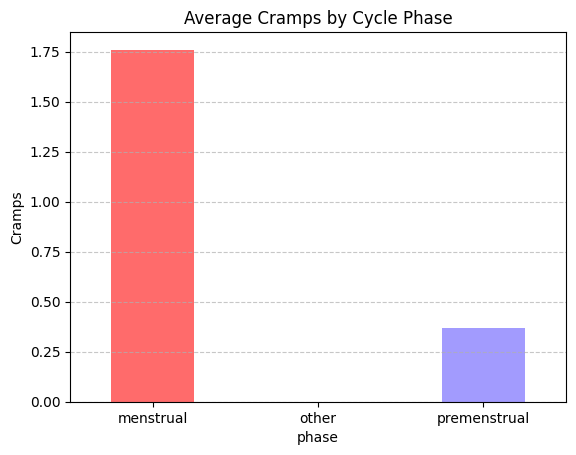

In [5]:
df.groupby("phase")["cramps"].mean().plot(
    kind="bar",
    color=["#ff6b6b", "#4ecdc4", "#a29bfe"]
)

plt.title("Average Cramps by Cycle Phase")
plt.ylabel("Cramps")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Cramps are highest during the menstrual phase and minimal during other phases.

## Energy Analysis

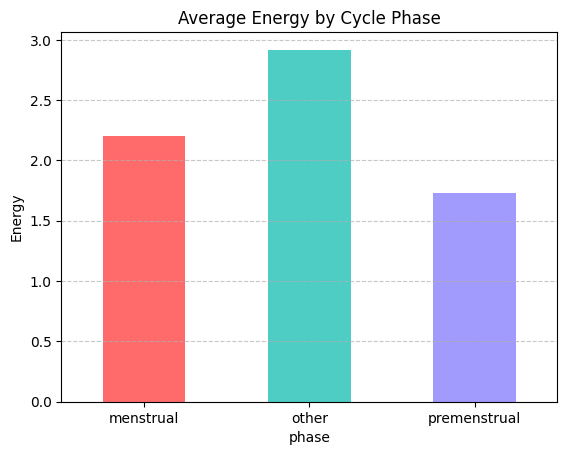

In [6]:
df.groupby("phase")["energy"].mean().plot(
    kind="bar",
    color=["#ff6b6b", "#4ecdc4", "#a29bfe"]
)

plt.title("Average Energy by Cycle Phase")
plt.ylabel("Energy")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Energy levels are highest during the non-menstrual phase and decrease during menstrual and premenstrual phases.

## Correlation Analysis

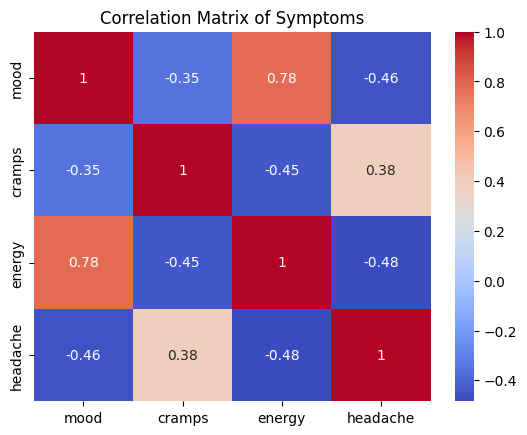

In [7]:
import seaborn as sns

corr = df[["mood", "cramps", "energy", "headache"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Symptoms")
plt.show()

The correlation matrix highlights relationships between different symptoms.

Cramps show a negative correlation with mood and energy, indicating that higher physical discomfort is associated with lower emotional well-being and energy levels.

These findings are consistent with the patterns observed in earlier visualizations.

## Symptom Trends Across Cycle

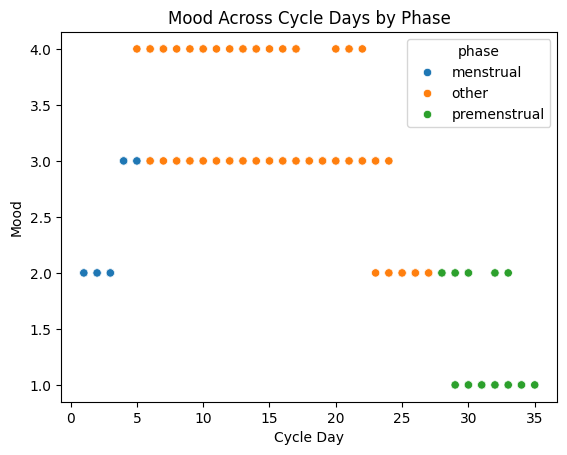

In [8]:
sns.scatterplot(data=df, x="cycle_day", y="mood", hue="phase")
plt.title("Mood Across Cycle Days by Phase")
plt.xlabel("Cycle Day")
plt.ylabel("Mood")
plt.show()

The scatter plot shows how mood changes across the cycle.

Different phases display distinct patterns with lower mood values appearing more frequently in premenstrual days and higher values during the non-menstrual phase.

### Energy Trends

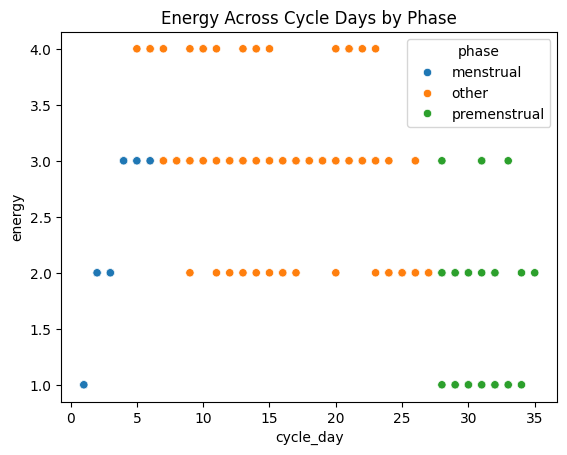

In [9]:
sns.scatterplot(data=df, x="cycle_day", y="energy", hue="phase")
plt.title("Energy Across Cycle Days by Phase")
plt.show()

The scatter plot shows how energy levels vary across the menstrual cycle.

Energy tends to be higher during the non-menstrual phase and decreases during menstrual and premenstrual phases. Lower energy levels are more frequently observed towards the end of the cycle, which aligns with the patterns identified in previous analyses.

This suggests that energy levels are influenced by cycle phases and are closely related to physical symptoms such as cramps.